In [2]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/ml_final_project

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/ml_final_project


In [3]:
from colab_setup import setup_project

drive_repo = setup_project(repo_url="https://github.com/ochiga07/ml_final_project.git")

import feature_pipeline
import importlib
importlib.reload(feature_pipeline)
from feature_pipeline import load_raw_data, run_feature_pipeline, split_and_save

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!pip install -q mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0

In [5]:
import mlflow
import dagshub

dagshub.init(repo_owner='aochi23', repo_name='ml_final_project', mlflow=True)
mlflow.set_experiment("ARIMA_Training")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=67527cae-fa8f-4f72-a367-02712c512e1f&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=8de744343f28f9cea7ac7cce8149a95c36269bc39d4f0402b7aaa54068082b20




Accessing as aochi23

Initialized MLflow to track repo "aochi23/ml_final_project"

Repository aochi23/ml_final_project initialized!

<Experiment: artifact_location='mlflow-artifacts:/d47f6bf42adf4ee98837955a7cd027d0', creation_time=1783704500360, effective_trace_archival_retention=None, experiment_id='3', last_update_time=1783704500360, lifecycle_stage='active', name='ARIMA_Training', tags={}, trace_location=None, workspace='default'>

In [6]:
train, test, features, stores = load_raw_data(path=f'{drive_repo}/data/')
full_df = run_feature_pipeline(train, test, features, stores)
processed_train, processed_test = split_and_save(full_df)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

In [8]:
with mlflow.start_run(run_name="ARIMA_Preprocessing"):
    non_sparse = processed_train[processed_train['is_sparse'] == False]
    volume_by_pair = non_sparse.groupby(['Store', 'Dept'])['Weekly_Sales'].sum().sort_values(ascending=False)
    n_total = len(volume_by_pair)

    np.random.seed(42)
    high_vol = volume_by_pair.iloc[:n_total // 3]
    mid_vol = volume_by_pair.iloc[n_total // 3: 2 * n_total // 3]
    low_vol = volume_by_pair.iloc[2 * n_total // 3:]

    sample_pairs = (list(high_vol.sample(5).index) +
        list(mid_vol.sample(5).index) + list(low_vol.sample(5).index))

    stationarity_results = []
    for store, dept in sample_pairs:
        subset = processed_train[
            (processed_train['Store'] == store) &
            (processed_train['Dept'] == dept)
        ].sort_values('Date')
        series = subset.set_index('Date')['Weekly_Sales']
        train_series = series[:-12]
        adf_pvalue = adfuller(train_series)[1]
        stationarity_results.append({
            'Store': store, 'Dept': dept,
            'n_weeks': len(series),
            'adf_pvalue': adf_pvalue,
            'stationary': adf_pvalue < 0.05
        })

    stationarity_df = pd.DataFrame(stationarity_results)
    n_stationary = stationarity_df['stationary'].sum()

    mlflow.log_param("min_weeks_threshold", 52)
    mlflow.log_param("n_series_sampled", len(sample_pairs))
    mlflow.log_param("sampling_strategy", "stratified_by_volume_5_5_5")
    mlflow.log_param("validation_weeks", 12)
    mlflow.log_metric("n_stationary_series", n_stationary)
    mlflow.log_metric("pct_stationary", n_stationary / len(sample_pairs))

    print(stationarity_df)
    print(f"\n{n_stationary}/{len(sample_pairs)} series are stationary (ADF with p < 0.05)")

    Store  Dept  n_weeks    adf_pvalue  stationary
0      11    79      143  1.934941e-01       False
1      40     9      143  5.822119e-02       False
2      37    95      143  1.684752e-03        True
3       6    87      143  7.791159e-01       False
4       8    87      143  8.701641e-01       False
5      24    25      143  1.498365e-07        True
6      32    16      143  1.842348e-03        True
7       6    25      143  8.387345e-04        True
8       8    22      143  2.004005e-03        True
9       9     3      143  6.580216e-05        True
10      1    27      143  1.078307e-03        True
11      5    55      143  4.146046e-03        True
12     13    27      143  2.386389e-06        True
13     10    36      143  1.272071e-03        True
14     10    45       79  1.566152e-03        True

11/15 series are stationary (ADF with p < 0.05)
🏃 View run ARIMA_Preprocessing at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/3/runs/7c50c37f35704852b9f132dd5fb

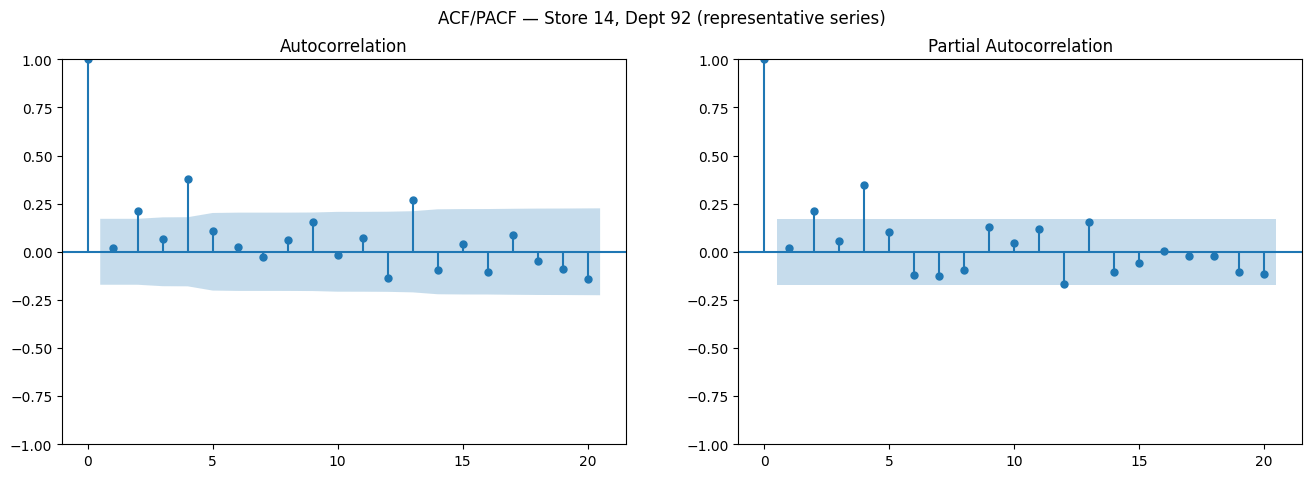

Order selected: ARIMA(1,1,1) — no seasonal component
🏃 View run ARIMA_Order_Selection at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/3/runs/7c0c739e20cc4f8abd7295fd591bc916
🧪 View experiment at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/3


In [9]:
with mlflow.start_run(run_name="ARIMA_Order_Selection"):
    rep_store, rep_dept = volume_by_pair.index[0]
    subset = processed_train[
        (processed_train['Store'] == rep_store) &
        (processed_train['Dept'] == rep_dept)
    ].sort_values('Date')
    rep_series = subset.set_index('Date')['Weekly_Sales'][:-12]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    plot_acf(rep_series, lags=20, ax=axes[0])
    plot_pacf(rep_series, lags=20, ax=axes[1])
    plt.suptitle(f'ACF/PACF — Store {rep_store}, Dept {rep_dept} (representative series)')
    acf_path = f"{drive_repo}/arima_acf_pacf.png"
    plt.savefig(acf_path)
    plt.show()

    mlflow.log_param("p", 1)
    mlflow.log_param("d", 1)
    mlflow.log_param("q", 1)
    mlflow.log_param("order_selection_method", "ACF_PACF_analysis")
    mlflow.log_param(
        "order_reasoning",
        "d=1: most individual series non-stationary. p=1,q=1: significant spike at lag 1 "
        "in PACF/ACF. Unlike SARIMA, no seasonal terms — ARIMA can't model the yearly "
        "(lag-52) pattern directly, which is expected to hurt it relative to SARIMA."
    )
    mlflow.log_artifact(acf_path)

    print("Order selected: ARIMA(1,1,1) — no seasonal component")

In [10]:
def wmae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)


def fit_and_evaluate_arima(series_df, store, dept, n_test=12, order=(1,1,1)):
    subset = series_df[
        (series_df['Store'] == store) &
        (series_df['Dept'] == dept)
    ].sort_values('Date')
    series = subset.set_index('Date')['Weekly_Sales']

    if len(series) < n_test + 20:
        return None

    train_series = series[:-n_test]
    val_series = series[-n_test:]
    holiday_val = subset['IsHoliday'].iloc[-n_test:].values

    try:
        model = ARIMA(train_series, order=order)
        results = model.fit()
        forecast = results.get_forecast(steps=n_test)
        pred_mean = forecast.predicted_mean

        mae   = mean_absolute_error(val_series, pred_mean)
        rmse  = np.sqrt(np.mean((val_series.values - pred_mean.values) ** 2))
        w_mae = wmae(val_series.values, pred_mean.values, holiday_val)

        return {
            'Store': store, 'Dept': dept,
            'n_weeks': len(series),
            'adf_pvalue': adfuller(train_series)[1],
            'mae': mae, 'rmse': rmse, 'wmae': w_mae, 'aic': results.aic,
            'series': series,
            'train_series': train_series,
            'val_series': val_series,
            'pred_mean': pred_mean,
            'results': results
        }
    except Exception as e:
        print(f"Failed — Store {store}, Dept {dept}: {e}")
        return None

In [11]:
arima_configs = [
    {"run_name": "ARIMA_Baseline_111", "order": (1,1,1)},
    {"run_name": "ARIMA_Order_211",    "order": (2,1,1)},
    {"run_name": "ARIMA_Order_112",    "order": (1,1,2)},
    {"run_name": "ARIMA_Order_212",    "order": (2,1,2)},
    {"run_name": "ARIMA_NoDiff_101",   "order": (1,0,1)},
    {"run_name": "ARIMA_HigherAR_311", "order": (3,1,1)},
]

In [12]:
import gc

sweep_results = []

for config in arima_configs:
    with mlflow.start_run(run_name=config["run_name"]):
        mlflow.log_param("order", str(config["order"]))

        metrics_only = []

        for store, dept in sample_pairs:
            result = fit_and_evaluate_arima(
                processed_train, store, dept,
                n_test=12,
                order=config["order"],
            )
            if result is not None:
                metrics_only.append({
                    'Store': result['Store'], 'Dept': result['Dept'],
                    'mae': result['mae'], 'rmse': result['rmse'],
                    'wmae': result['wmae'], 'aic': result['aic']
                })
            del result

        summary_df = pd.DataFrame(metrics_only)

        mean_mae    = summary_df['mae'].mean()
        median_mae  = summary_df['mae'].median()
        mean_rmse   = summary_df['rmse'].mean()
        mean_wmae   = summary_df['wmae'].mean()
        median_wmae = summary_df['wmae'].median()
        mean_aic    = summary_df['aic'].mean()

        mlflow.log_metric("mean_mae", mean_mae)
        mlflow.log_metric("median_mae", median_mae)
        mlflow.log_metric("mean_rmse", mean_rmse)
        mlflow.log_metric("mean_wmae", mean_wmae)
        mlflow.log_metric("median_wmae", median_wmae)
        mlflow.log_metric("mean_aic", mean_aic)
        mlflow.log_metric("n_series_evaluated", len(metrics_only))

        sweep_results.append({
            "run_name": config["run_name"],
            "order": config["order"],
            "mean_mae": mean_mae,
            "mean_rmse": mean_rmse,
            "mean_wmae": mean_wmae,
            "median_wmae": median_wmae,
        })

        print(f"{config['run_name']}: mean_mae={mean_mae:.2f}, mean_wmae={mean_wmae:.2f}")

        gc.collect()

ARIMA_Baseline_111: mean_mae=2608.12, mean_wmae=2454.70
🏃 View run ARIMA_Baseline_111 at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/3/runs/0b27c82306a247b5ada6d4c23bc62477
🧪 View experiment at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/3
ARIMA_Order_211: mean_mae=2635.74, mean_wmae=2492.96
🏃 View run ARIMA_Order_211 at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/3/runs/1bba532ebdbc4618be53049bc3d3d884
🧪 View experiment at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/3
ARIMA_Order_112: mean_mae=2524.87, mean_wmae=2390.90
🏃 View run ARIMA_Order_112 at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/3/runs/247df9478051488f9406f9d5db79bf89
🧪 View experiment at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/3
ARIMA_Order_212: mean_mae=2500.19, mean_wmae=2384.75
🏃 View run ARIMA_Order_212 at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/3/ru

In [13]:
from tqdm.auto import tqdm

class MultiSeriesARIMA(BaseEstimator, RegressorMixin):
    def __init__(self, order=(1,1,1)):
        self.order = order

    def fit(self, X, y=None):
        raise NotImplementedError("Populate models_/skipped_series_/global_mean_ directly instead of calling fit().")

    def predict(self, X):
        preds = pd.Series(index=X.index, dtype=float)
        for (store, dept), grp in X.groupby(['Store', 'Dept']):
            grp = grp.sort_values('Date')
            key = (store, dept)
            n_steps = len(grp)
            if key in self.models_:
                forecast = self.models_[key].get_forecast(steps=n_steps)
                preds.loc[grp.index] = forecast.predicted_mean.values
            else:
                preds.loc[grp.index] = self.global_mean_
        return preds.values

In [14]:
best_config = min(sweep_results, key=lambda r: r['mean_wmae'])

print(f"Best config from sweep: {best_config['run_name']}")
print(f"  order={best_config['order']}")
print(f"  mean_wmae={best_config['mean_wmae']:.2f}")

Best config from sweep: ARIMA_NoDiff_101
  order=(1, 0, 1)
  mean_wmae=2187.49


In [15]:
with mlflow.start_run(run_name="ARIMA_Final_Refit"):
    mlflow.log_param("order", str(best_config["order"]))
    mlflow.log_param("selected_by", "min_mean_wmae_from_sweep")
    mlflow.log_param("n_series", len(sample_pairs))

    fitted = {}
    skipped = []

    for store, dept in tqdm(sample_pairs, desc="Refitting best config on full series"):
        subset = processed_train[
            (processed_train['Store'] == store) &
            (processed_train['Dept'] == dept)
        ].sort_values('Date')
        series = subset.set_index('Date')['Weekly_Sales'].asfreq('W-FRI')

        if len(series) < 20:
            skipped.append((store, dept))
            continue

        try:
            model = ARIMA(series, order=best_config["order"])
            fitted[(store, dept)] = model.fit()
        except Exception:
            skipped.append((store, dept))

    mlflow.log_metric("n_series_fit", len(fitted))
    mlflow.log_metric("n_series_skipped", len(skipped))
    print(f"Fitted: {len(fitted)} / {len(sample_pairs)}   Skipped: {len(skipped)}")

Refitting best config on full series:   0%|          | 0/15 [00:00<?, ?it/s]

Fitted: 15 / 15   Skipped: 0
🏃 View run ARIMA_Final_Refit at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/3/runs/8ec3d6f380934cf3bc9bf6f33e39f1c9
🧪 View experiment at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/3


In [16]:
arima_model = MultiSeriesARIMA(order=best_config["order"])
arima_model.models_ = fitted
arima_model.skipped_series_ = skipped
arima_model.global_mean_ = processed_train['Weekly_Sales'].mean()

best_arima_pipeline = Pipeline([
    ('arima', arima_model)
])

print(f"Reconstructed pipeline — {len(arima_model.models_)} series fit, "
      f"{len(arima_model.skipped_series_)} skipped")

Reconstructed pipeline — 15 series fit, 0 skipped


In [17]:
with mlflow.start_run(run_name="ARIMA_MultiSeries_Final"):
    mlflow.log_param("order", str(best_config["order"]))
    mlflow.log_param("selected_from_sweep", best_config["run_name"])
    mlflow.log_param("n_series_fit", len(best_arima_pipeline.named_steps['arima'].models_))
    mlflow.log_param("n_series_skipped", len(best_arima_pipeline.named_steps['arima'].skipped_series_))
    mlflow.log_param("sampling_strategy", "stratified_by_volume_5_5_5 (same 15 series used in sweep)")

    mlflow.log_metric("sweep_mean_mae", best_config['mean_mae'])
    mlflow.log_metric("sweep_mean_wmae", best_config['mean_wmae'])
    mlflow.log_metric("sweep_median_wmae", best_config['median_wmae'])

    mlflow.sklearn.log_model(
        sk_model=best_arima_pipeline,
        name="arima_multiseries_pipeline",
        serialization_format="cloudpickle",
    )

    print(f"Saved ARIMA pipeline — {len(best_arima_pipeline.named_steps['arima'].models_)} series fit, "
          f"sweep mean_wmae={best_config['mean_wmae']:.2f}")

2026/07/11 15:24:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Saved ARIMA pipeline — 15 series fit, sweep mean_wmae=2187.49
🏃 View run ARIMA_MultiSeries_Final at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/3/runs/e31d87922b054c99a9a5c80e12726d64
🧪 View experiment at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/3
